# Exercises XP Gold - Week 4 Day 1

In [19]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
import seaborn as sns

plt.style.use('default')
plt.rcParams['figure.figsize'] = (10, 6)

## Exercise 1: Bar Graph



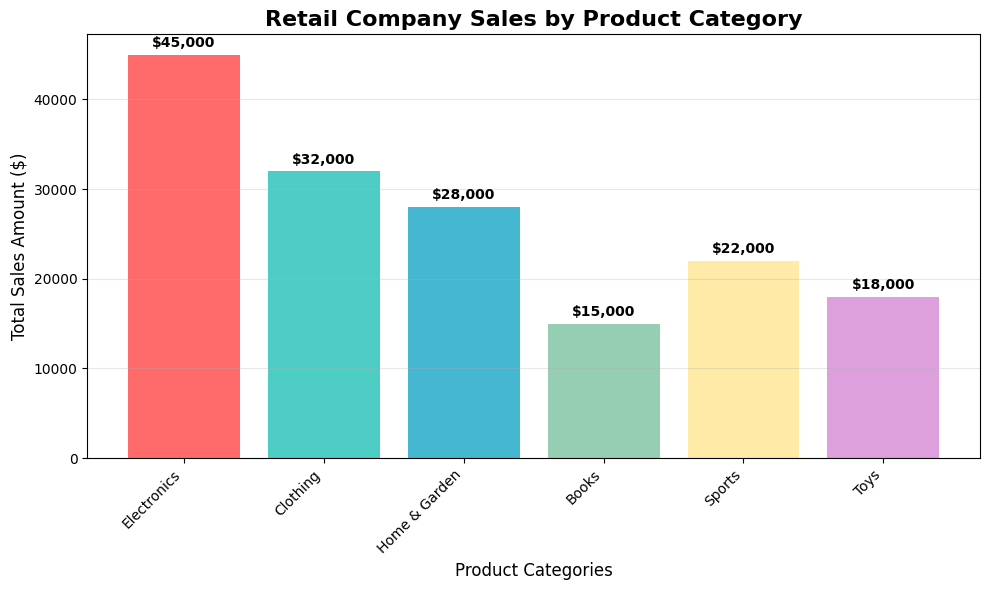

Total Sales Across All Categories: $160,000
Average Sales per Category: $26,667
Best Performing Category: Electronics ($45,000)


In [3]:
# Create fictional retail sales data
product_categories = ['Electronics', 'Clothing', 'Home & Garden', 'Books', 'Sports', 'Toys']
sales_amounts = [45000, 32000, 28000, 15000, 22000, 18000]

# Create the bar graph
plt.figure(figsize=(10, 6))
bars = plt.bar(product_categories, sales_amounts, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD'])

# Customize the plot
plt.title('Retail Company Sales by Product Category', fontsize=16, fontweight='bold')
plt.xlabel('Product Categories', fontsize=12)
plt.ylabel('Total Sales Amount ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 500,
             f'${height:,.0f}', ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary statistics
total_sales = sum(sales_amounts)
print(f"Total Sales Across All Categories: ${total_sales:,.0f}")
print(f"Average Sales per Category: ${total_sales/len(sales_amounts):,.0f}")
print(f"Best Performing Category: {product_categories[sales_amounts.index(max(sales_amounts))]} (${max(sales_amounts):,.0f})")

## Exercise 2: Hierarchical Indexing



In [4]:
# Create sample weather data with hierarchical indexing
np.random.seed(42)

# Create hierarchical data
countries = ['Canada', 'USA', 'Canada', 'USA', 'Canada']
cities = ['Toronto', 'New York', 'Vancouver', 'Los Angeles', 'Montreal']
dates = pd.date_range('2023-06-01', periods=30, freq='D')

# Create DataFrame with all combinations
data = []
for country in ['Canada', 'USA']:
    country_cities = ['Toronto', 'Vancouver', 'Montreal'] if country == 'Canada' else ['New York', 'Los Angeles']
    for city in country_cities:
        for date in dates:
            # Generate realistic summer temperatures (higher chance of >30°C)
            base_temp = np.random.normal(25, 8)  # Base temperature around 25°C
            if city in ['Los Angeles', 'Vancouver']:
                base_temp += 3  # Warmer climate
            temperature = max(base_temp, 10)  # Minimum 10°C
            data.append([country, city, date, temperature])

# Create DataFrame
weather_df = pd.DataFrame(data, columns=['Country', 'City', 'Date', 'Temperature'])

# Set hierarchical index
weather_df.set_index(['Country', 'City', 'Date'], inplace=True)

print("Sample of weather data with hierarchical indexing:")
print(weather_df.head(10))
print(f"\nDataFrame shape: {weather_df.shape}")
print(f"Index levels: {weather_df.index.names}")

Sample of weather data with hierarchical indexing:
                            Temperature
Country City    Date                   
Canada  Toronto 2023-06-01    28.973713
                2023-06-02    23.893886
                2023-06-03    30.181508
                2023-06-04    37.184239
                2023-06-05    23.126773
                2023-06-06    23.126904
                2023-06-07    37.633703
                2023-06-08    31.139478
                2023-06-09    21.244205
                2023-06-10    29.340480

DataFrame shape: (150, 1)
Index levels: ['Country', 'City', 'Date']


In [5]:
# Filter for Canadian cities with temperature > 30°C
hot_days_canada = weather_df.loc['Canada'][weather_df.loc['Canada']['Temperature'] > 30]

print("Days when temperature exceeded 30°C in Canadian cities:")
print("=" * 60)
print(hot_days_canada)
print(f"\nTotal hot days in Canada: {len(hot_days_canada)}")

# Alternative method using query
hot_days_query = weather_df.query("Temperature > 30").loc['Canada']
print(f"\nUsing query method - Total hot days in Canada: {len(hot_days_query)}")

# Group by city to see distribution
hot_days_by_city = hot_days_canada.groupby('City').size()
print(f"\nHot days by Canadian city:")
print(hot_days_by_city)

# Explanation of hierarchical indexing benefits
print("\n" + "="*60)
print("BENEFITS OF HIERARCHICAL INDEXING:")
print("="*60)
print("1. Efficient filtering by country using .loc['Canada']")
print("2. Natural organization of data by geographic hierarchy") 
print("3. Easy grouping and aggregation at different levels")
print("4. Memory efficient storage of related data")
print("5. Intuitive data access patterns for nested structures")

Days when temperature exceeded 30°C in Canadian cities:
                      Temperature
City      Date                   
Toronto   2023-06-03    30.181508
          2023-06-04    37.184239
          2023-06-07    37.633703
          2023-06-08    31.139478
          2023-06-21    36.725190
Vancouver 2023-06-02    42.818225
          2023-06-05    34.580359
          2023-06-11    33.907733
          2023-06-18    36.456978
          2023-06-19    30.748946
          2023-06-21    30.592672
          2023-06-24    32.893410
          2023-06-25    36.247996
          2023-06-26    35.450241
          2023-06-29    30.650107
          2023-06-30    35.804361
Montreal  2023-06-05    31.500207
          2023-06-06    35.849920
          2023-06-08    33.028263
          2023-06-12    37.304293
          2023-06-14    37.517149
          2023-06-16    31.575220
          2023-06-23    36.823152
          2023-06-27    32.323217

Total hot days in Canada: 24

Using query method - Total ho

## Exercise 3: Advanced Filtering with Hierarchical Indices



In [6]:
# Create employee dataset with hierarchical indexing
np.random.seed(123)

departments = ['Engineering', 'Sales', 'Marketing', 'HR', 'Finance']
positions = ['Junior', 'Senior', 'Lead', 'Manager']

# Create employee data
employee_data = []
employee_id = 1000

for dept in departments:
    for pos in positions:
        for i in range(np.random.randint(3, 8)):  # 3-7 employees per position
            # Generate realistic salaries based on department and position
            base_salary = {
                'Engineering': {'Junior': 55000, 'Senior': 75000, 'Lead': 95000, 'Manager': 120000},
                'Sales': {'Junior': 40000, 'Senior': 60000, 'Lead': 80000, 'Manager': 100000},
                'Marketing': {'Junior': 42000, 'Senior': 58000, 'Lead': 75000, 'Manager': 95000},
                'HR': {'Junior': 38000, 'Senior': 52000, 'Lead': 70000, 'Manager': 85000},
                'Finance': {'Junior': 45000, 'Senior': 65000, 'Lead': 85000, 'Manager': 110000}
            }[dept][pos]
            
            salary = base_salary + np.random.randint(-10000, 15000)
            salary = max(salary, 30000)  # Minimum salary
            
            name = f"Employee_{employee_id}"
            employee_data.append([dept, pos, employee_id, name, salary])
            employee_id += 1

# Create DataFrame
employee_df = pd.DataFrame(employee_data, columns=['Department', 'Position', 'EmployeeID', 'Name', 'Salary'])

# Set hierarchical index
employee_df.set_index(['Department', 'Position'], inplace=True)

print("Employee dataset with hierarchical indexing:")
print(employee_df.head(15))
print(f"\nDataset shape: {employee_df.shape}")
print(f"Departments: {employee_df.index.get_level_values(0).unique().tolist()}")

Employee dataset with hierarchical indexing:
                      EmployeeID           Name  Salary
Department  Position                                   
Engineering Junior          1000  Employee_1000   66602
            Junior          1001  Employee_1001   60377
            Junior          1002  Employee_1002   52763
            Junior          1003  Employee_1003   58435
            Junior          1004  Employee_1004   68766
            Senior          1005  Employee_1005   65096
            Senior          1006  Employee_1006   87641
            Senior          1007  Employee_1007   88166
            Senior          1008  Employee_1008   85527
            Lead            1009  Employee_1009   90664
            Lead            1010  Employee_1010   85942
            Lead            1011  Employee_1011  107752
            Lead            1012  Employee_1012   85111
            Manager         1013  Employee_1013  127747
            Manager         1014  Employee_1014  112894

Da

In [7]:
# Filter employees with salary > 50,000 within each department
high_salary_employees = employee_df[employee_df['Salary'] > 50000]

print("Employees with Salary > $50,000 by Department:")
print("=" * 60)

for department in employee_df.index.get_level_values(0).unique():
    dept_high_salary = high_salary_employees.loc[department]
    print(f"\n{department.upper()} DEPARTMENT:")
    print(f"High salary employees: {len(dept_high_salary)}")
    print(dept_high_salary[['Name', 'Salary']].sort_values('Salary', ascending=False))
    print(f"Average salary for high earners: ${dept_high_salary['Salary'].mean():,.0f}")

# Summary statistics
print("\n" + "=" * 60)
print("SUMMARY STATISTICS:")
print("=" * 60)
total_high_salary = len(high_salary_employees)
total_employees = len(employee_df)
percentage = (total_high_salary / total_employees) * 100

print(f"Total employees with salary > $50,000: {total_high_salary}")
print(f"Total employees: {total_employees}")
print(f"Percentage of high earners: {percentage:.1f}%")

# Count by department
dept_counts = high_salary_employees.groupby('Department').size()
print(f"\nHigh earners by department:")&x
print(dept_counts)

Employees with Salary > $50,000 by Department:

ENGINEERING DEPARTMENT:
High salary employees: 17
                   Name  Salary
Position                       
Manager   Employee_1013  127747
Manager   Employee_1016  124944
Manager   Employee_1015  113325
Manager   Employee_1014  112894
Lead      Employee_1011  107752
Lead      Employee_1009   90664
Senior    Employee_1007   88166
Senior    Employee_1006   87641
Lead      Employee_1010   85942
Senior    Employee_1008   85527
Lead      Employee_1012   85111
Junior    Employee_1004   68766
Junior    Employee_1000   66602
Senior    Employee_1005   65096
Junior    Employee_1001   60377
Junior    Employee_1003   58435
Junior    Employee_1002   52763
Average salary for high earners: $87,162

SALES DEPARTMENT:
High salary employees: 16
                   Name  Salary
Position                       
Manager   Employee_1034  112497
Manager   Employee_1031  110693
Manager   Employee_1030  107766
Manager   Employee_1035  106972
Manager   Employ

NameError: name 'x' is not defined

## Exercise 4: Combined Filtering and Hierarchical Indexing



In [8]:
# Create health data with hierarchical indexing
np.random.seed(456)

countries = ['USA', 'Canada', 'UK', 'Germany']
cities = {
    'USA': ['New York', 'Los Angeles', 'Chicago', 'Houston', 'Phoenix'],
    'Canada': ['Toronto', 'Montreal', 'Vancouver', 'Calgary'],
    'UK': ['London', 'Manchester', 'Birmingham', 'Liverpool'],
    'Germany': ['Berlin', 'Munich', 'Hamburg', 'Frankfurt']
}

hospital_types = ['General Hospital', 'Medical Center', 'Regional Hospital', 'University Hospital', 'Specialty Clinic']

# Create health data
health_data = []

for country in countries:
    for city in cities[country]:
        # Each city has 2-5 hospitals
        for i in range(np.random.randint(2, 6)):
            hospital_name = f"{city} {np.random.choice(hospital_types)} {i+1}"
            # Generate patient numbers (some > 500, some < 500)
            patients = np.random.randint(150, 1200)
            health_data.append([country, city, hospital_name, patients])

# Create DataFrame
health_df = pd.DataFrame(health_data, columns=['Country', 'City', 'Hospital', 'Patients'])

# Set hierarchical index
health_df.set_index(['Country', 'City'], inplace=True)

print("Health data with hierarchical indexing:")
print(health_df.head(15))
print(f"\nDataset shape: {health_df.shape}")

# Show total patients by country
country_totals = health_df.groupby('Country')['Patients'].sum().sort_values(ascending=False)
print(f"\nTotal patients by country:")
print(country_totals)

Health data with hierarchical indexing:
                                            Hospital  Patients
Country City                                                  
USA     New York      New York University Hospital 1       751
        New York        New York Regional Hospital 2       645
        New York         New York Specialty Clinic 3       394
        New York         New York Specialty Clinic 4       195
        New York         New York Specialty Clinic 5       347
        Los Angeles   Los Angeles Specialty Clinic 1       952
        Los Angeles  Los Angeles Regional Hospital 2       666
        Los Angeles   Los Angeles General Hospital 3       468
        Los Angeles   Los Angeles General Hospital 4       703
        Chicago           Chicago General Hospital 1       962
        Chicago          Chicago Regional Hospital 2       185
        Chicago           Chicago General Hospital 3      1094
        Chicago        Chicago University Hospital 4       889
        Houston

In [9]:
# Filter USA cities with hospitals having > 500 patients
usa_high_patient_hospitals = health_df.loc['USA'][health_df.loc['USA']['Patients'] > 500]

print("USA hospitals with more than 500 patients:")
print("=" * 60)
print(usa_high_patient_hospitals)

# Group by city to see which cities have large hospitals
usa_cities_with_large_hospitals = usa_high_patient_hospitals.groupby('City').agg({
    'Hospital': 'count',
    'Patients': ['sum', 'mean', 'max']
}).round(0)

usa_cities_with_large_hospitals.columns = ['Large_Hospitals_Count', 'Total_Patients', 'Avg_Patients', 'Max_Patients']

print(f"\nUSA cities with large hospitals (>500 patients):")
print(usa_cities_with_large_hospitals)

# Alternative approach: Show all cities in USA and their hospital statistics
print(f"\nDetailed analysis of all USA cities:")
print("=" * 60)

for city in health_df.loc['USA'].index.get_level_values(0).unique():
    city_data = health_df.loc['USA'].loc[city]
    large_hospitals = city_data[city_data['Patients'] > 500]
    
    print(f"\n{city}:")
    print(f"  Total hospitals: {len(city_data)}")
    print(f"  Large hospitals (>500 patients): {len(large_hospitals)}")
    print(f"  Total patients in city: {city_data['Patients'].sum():,}")
    
    if len(large_hospitals) > 0:
        print(f"  Large hospitals:")
        for _, hospital in large_hospitals.iterrows():
            print(f"    - {hospital['Hospital']}: {hospital['Patients']} patients")

USA hospitals with more than 500 patients:
                                    Hospital  Patients
City                                                  
New York      New York University Hospital 1       751
New York        New York Regional Hospital 2       645
Los Angeles   Los Angeles Specialty Clinic 1       952
Los Angeles  Los Angeles Regional Hospital 2       666
Los Angeles   Los Angeles General Hospital 4       703
Chicago           Chicago General Hospital 1       962
Chicago           Chicago General Hospital 3      1094
Chicago        Chicago University Hospital 4       889
Houston          Houston Regional Hospital 1       556
Houston        Houston University Hospital 2       846
Phoenix             Phoenix Medical Center 2       629
Phoenix        Phoenix University Hospital 3       683

USA cities with large hospitals (>500 patients):
             Large_Hospitals_Count  Total_Patients  Avg_Patients  Max_Patients
City                                                      

## Exercise 5: Data Visualisation Using MatPlotlib


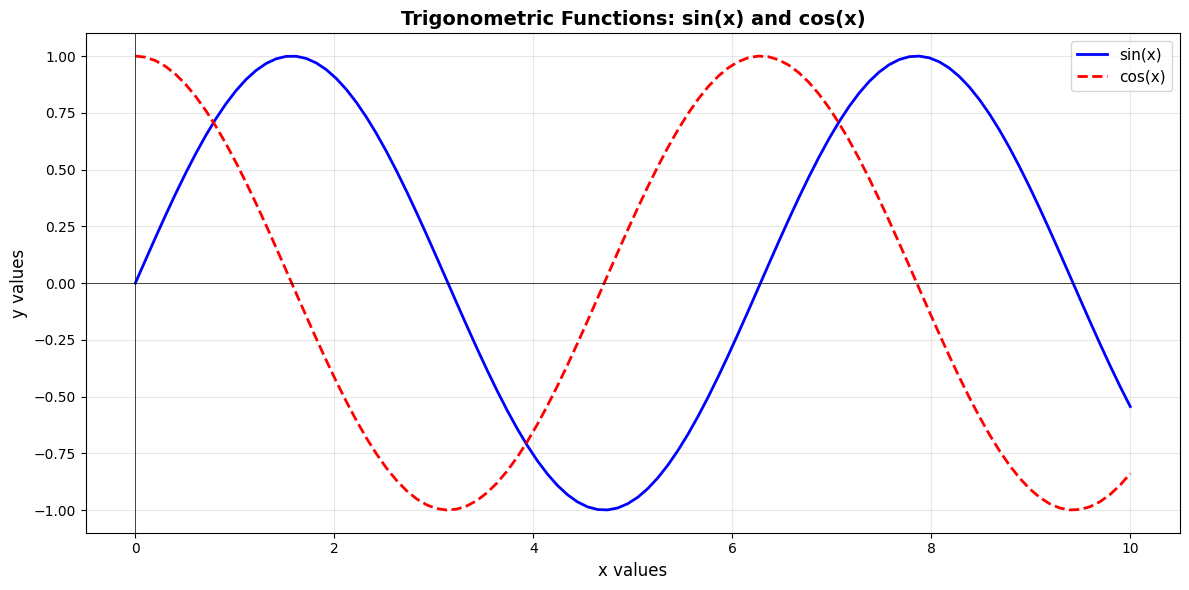

Plot 1: Line graphs for sin(x) and cos(x) from 0 to 10


In [10]:
# 5.1 - Line graphs for sin(x) and cos(x)
x = np.linspace(0, 10, 100)
y_sin = np.sin(x)
y_cos = np.cos(x)

plt.figure(figsize=(12, 6))
plt.plot(x, y_sin, label='sin(x)', color='blue', linestyle='-', linewidth=2)
plt.plot(x, y_cos, label='cos(x)', color='red', linestyle='--', linewidth=2)

plt.title('Trigonometric Functions: sin(x) and cos(x)', fontsize=14, fontweight='bold')
plt.xlabel('x values', fontsize=12)
plt.ylabel('y values', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='black', linewidth=0.5)
plt.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print("Plot 1: Line graphs for sin(x) and cos(x) from 0 to 10")

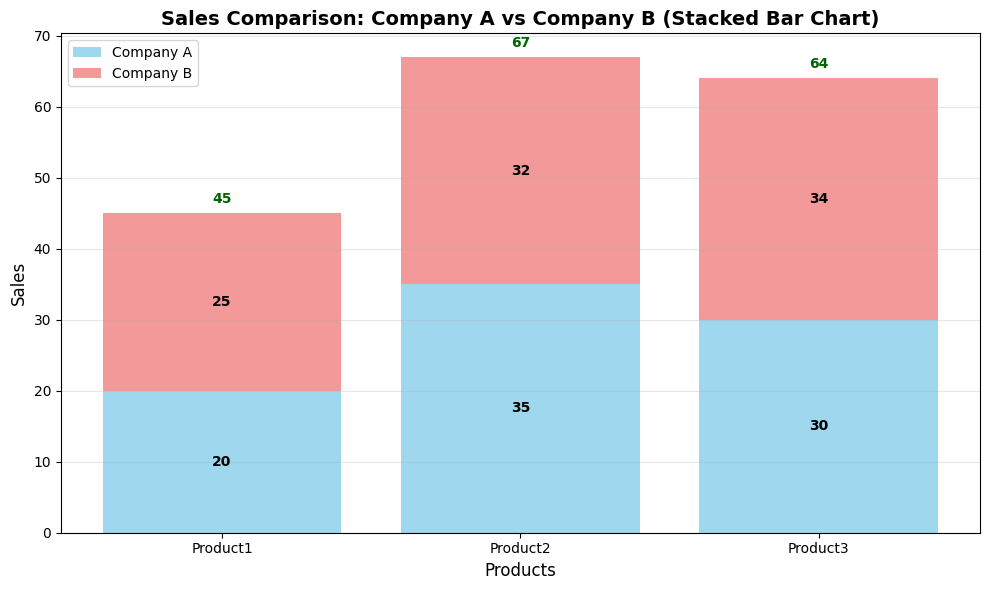

Plot 2: Stacked bar chart comparing Company A and Company B sales


In [11]:
# 5.2 - Stacked bar chart for company sales data
products = ['Product1', 'Product2', 'Product3']
company_a = [20, 35, 30]
company_b = [25, 32, 34]

x_pos = np.arange(len(products))

plt.figure(figsize=(10, 6))
plt.bar(x_pos, company_a, label='Company A', color='skyblue', alpha=0.8)
plt.bar(x_pos, company_b, bottom=company_a, label='Company B', color='lightcoral', alpha=0.8)

plt.title('Sales Comparison: Company A vs Company B (Stacked Bar Chart)', fontsize=14, fontweight='bold')
plt.xlabel('Products', fontsize=12)
plt.ylabel('Sales', fontsize=12)
plt.xticks(x_pos, products)
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (a, b) in enumerate(zip(company_a, company_b)):
    plt.text(i, a/2, str(a), ha='center', va='center', fontweight='bold')
    plt.text(i, a + b/2, str(b), ha='center', va='center', fontweight='bold')
    plt.text(i, a + b + 1, str(a + b), ha='center', va='bottom', fontweight='bold', color='darkgreen')

plt.tight_layout()
plt.show()

print("Plot 2: Stacked bar chart comparing Company A and Company B sales")

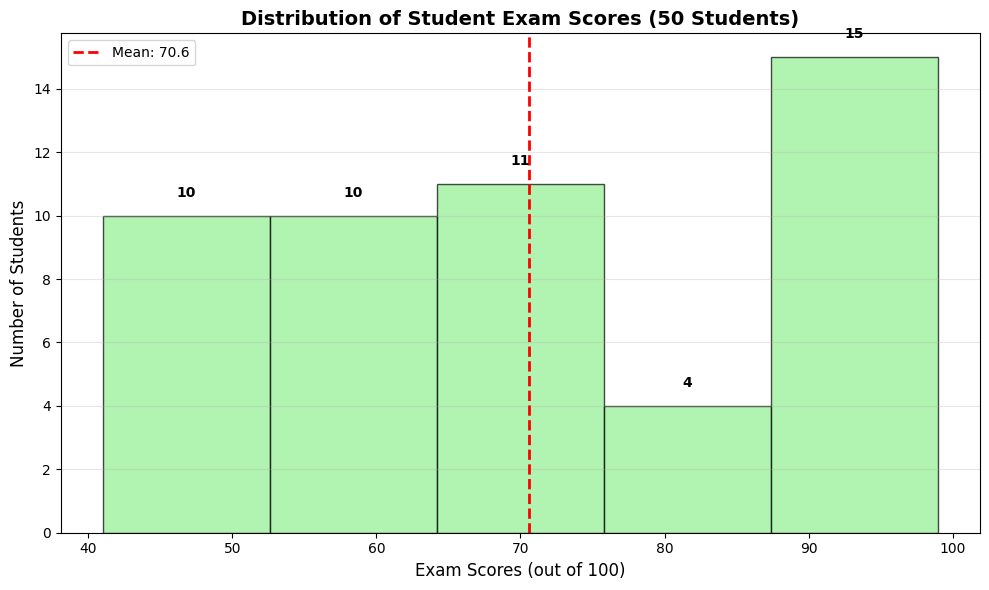

Plot 3: Histogram of exam scores
Mean score: 70.56
Standard deviation: 19.02
Score distribution: {'40-52': 10, '52-64': 10, '64-76': 11, '76-88': 4, '88-100': 15}


In [12]:
# 5.3 - Histogram for student exam scores
np.random.seed(789)
student_scores = np.random.randint(40, 100, 50)  # 50 students, scores between 40-100

plt.figure(figsize=(10, 6))
n, bins, patches = plt.hist(student_scores, bins=5, color='lightgreen', alpha=0.7, edgecolor='black', linewidth=1)

plt.title('Distribution of Student Exam Scores (50 Students)', fontsize=14, fontweight='bold')
plt.xlabel('Exam Scores (out of 100)', fontsize=12)
plt.ylabel('Number of Students', fontsize=12)
plt.grid(axis='y', alpha=0.3)

# Add statistics text
mean_score = np.mean(student_scores)
std_score = np.std(student_scores)
plt.axvline(mean_score, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_score:.1f}')
plt.legend()

# Add count labels on bars
for i in range(len(n)):
    plt.text(bins[i] + (bins[i+1] - bins[i])/2, n[i] + 0.5, str(int(n[i])), 
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Plot 3: Histogram of exam scores")
print(f"Mean score: {mean_score:.2f}")
print(f"Standard deviation: {std_score:.2f}")
print(f"Score distribution: {dict(zip(['40-52', '52-64', '64-76', '76-88', '88-100'], [int(x) for x in n]))}")

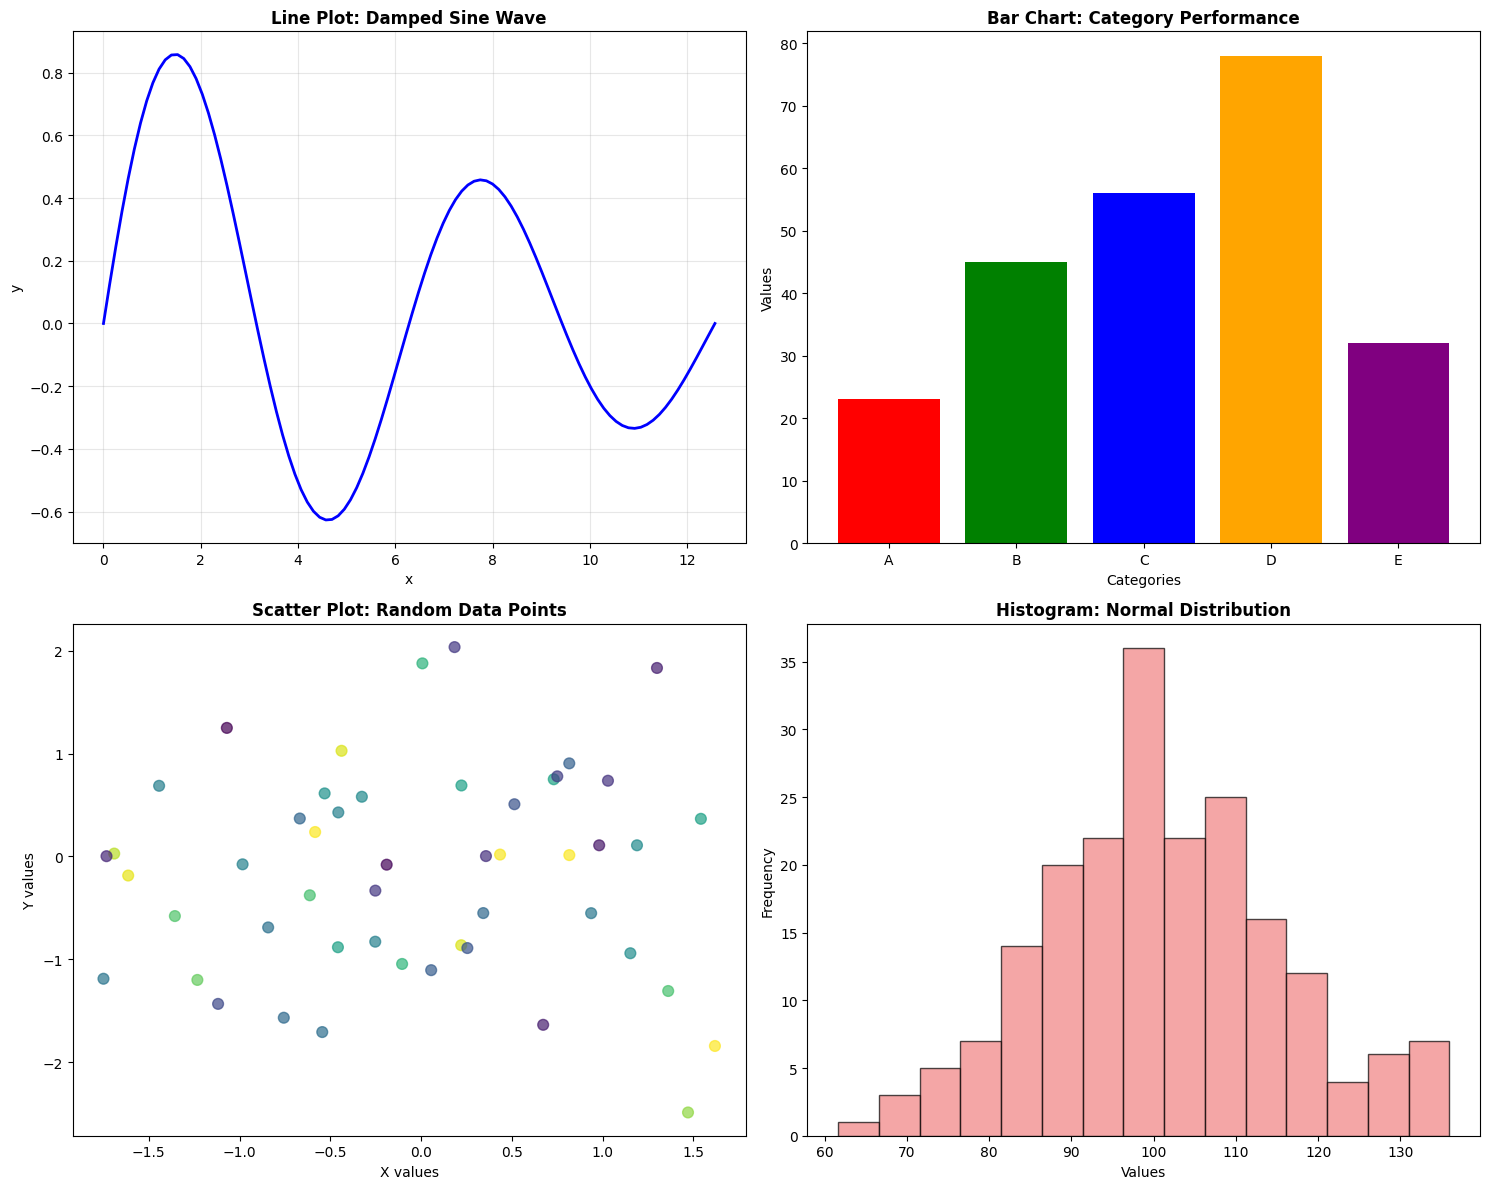

Plot 4: 2x2 subplot with line plot, bar chart, scatter plot, and histogram


In [13]:
# 5.4 - 2x2 subplot with different plot types
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Subplot 1: Line plot
x_line = np.linspace(0, 4*np.pi, 100)
y_line = np.sin(x_line) * np.exp(-x_line/10)
axes[0, 0].plot(x_line, y_line, color='blue', linewidth=2)
axes[0, 0].set_title('Line Plot: Damped Sine Wave', fontweight='bold')
axes[0, 0].set_xlabel('x')
axes[0, 0].set_ylabel('y')
axes[0, 0].grid(True, alpha=0.3)

# Subplot 2: Bar chart
categories = ['A', 'B', 'C', 'D', 'E']
values = [23, 45, 56, 78, 32]
axes[0, 1].bar(categories, values, color=['red', 'green', 'blue', 'orange', 'purple'])
axes[0, 1].set_title('Bar Chart: Category Performance', fontweight='bold')
axes[0, 1].set_xlabel('Categories')
axes[0, 1].set_ylabel('Values')

# Subplot 3: Scatter plot
np.random.seed(100)
x_scatter = np.random.randn(50)
y_scatter = np.random.randn(50)
colors = np.random.rand(50)
axes[1, 0].scatter(x_scatter, y_scatter, c=colors, alpha=0.7, s=60)
axes[1, 0].set_title('Scatter Plot: Random Data Points', fontweight='bold')
axes[1, 0].set_xlabel('X values')
axes[1, 0].set_ylabel('Y values')

# Subplot 4: Histogram
np.random.seed(200)
hist_data = np.random.normal(100, 15, 200)
axes[1, 1].hist(hist_data, bins=15, color='lightcoral', alpha=0.7, edgecolor='black')
axes[1, 1].set_title('Histogram: Normal Distribution', fontweight='bold')
axes[1, 1].set_xlabel('Values')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print("Plot 4: 2x2 subplot with line plot, bar chart, scatter plot, and histogram")

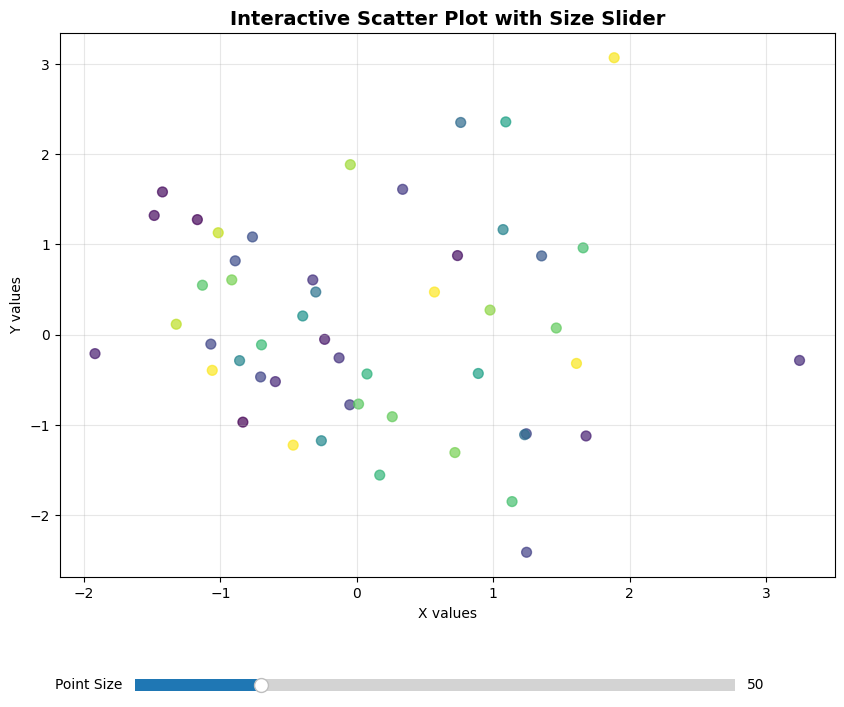

Plot 5: Interactive scatter plot with slider to control point size
Use the slider at the bottom to adjust the size of scatter plot points


In [14]:
# 5.5 - Interactive scatter plot with slider
fig, ax = plt.subplots(figsize=(10, 8))
plt.subplots_adjust(bottom=0.2)

# Generate random data points
np.random.seed(300)
n_points = 50
x_data = np.random.randn(n_points)
y_data = np.random.randn(n_points)
colors = np.random.rand(n_points)

# Initial scatter plot
scatter = ax.scatter(x_data, y_data, c=colors, alpha=0.7, s=50)
ax.set_title('Interactive Scatter Plot with Size Slider', fontsize=14, fontweight='bold')
ax.set_xlabel('X values')
ax.set_ylabel('Y values')
ax.grid(True, alpha=0.3)

# Create slider
ax_slider = plt.axes([0.2, 0.05, 0.6, 0.03])
slider = Slider(ax_slider, 'Point Size', 10, 200, valinit=50, valfmt='%0.0f')

# Function to update scatter plot
def update(val):
    size = slider.val
    scatter.set_sizes([size] * n_points)
    fig.canvas.draw()

slider.on_changed(update)

plt.show()

print("Plot 5: Interactive scatter plot with slider to control point size")
print("Use the slider at the bottom to adjust the size of scatter plot points")

## Exercise 6: Data Visualisation

**Instructions:** Using the dataset: sales_data.csv
1. Calculate the total revenue generated by the company over the entire year
2. Find the product that had the highest revenue and determine how much revenue it generated
3. Compute the average price of a product sold by the company

In [15]:
# Check if sales_data.csv exists, if not create sample data
import os

if os.path.exists('sales_data.csv'):
    print("Loading existing sales_data.csv file...")
    sales_df = pd.read_csv('sales_data.csv')
else:
    print("sales_data.csv not found. Creating sample sales data...")
    
    # Create sample sales data
    np.random.seed(555)
    
    # Generate realistic sales data for a year
    products = ['Laptop', 'Smartphone', 'Tablet', 'Headphones', 'Smartwatch', 'Camera', 'Speaker', 'Monitor']
    months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    
    sales_data = []
    
    for month in months:
        for product in products:
            # Generate random sales data
            units_sold = np.random.randint(50, 500)
            base_prices = {
                'Laptop': 800, 'Smartphone': 600, 'Tablet': 300, 'Headphones': 150,
                'Smartwatch': 250, 'Camera': 450, 'Speaker': 100, 'Monitor': 200
            }
            price_per_unit = base_prices[product] + np.random.randint(-50, 100)
            revenue = units_sold * price_per_unit
            
            sales_data.append([month, product, units_sold, price_per_unit, revenue])
    
    sales_df = pd.DataFrame(sales_data, columns=['Month', 'Product', 'Units_Sold', 'Price_Per_Unit', 'Revenue'])
    
    # Save to CSV for future use
    sales_df.to_csv('sales_data.csv', index=False)
    print("Sample data created and saved as sales_data.csv")

print("\nSales data overview:")
print(sales_df.head(10))
print(f"\nDataset shape: {sales_df.shape}")
print(f"Columns: {sales_df.columns.tolist()}")
print(f"Products: {sales_df['Product'].unique().tolist()}")
print(f"Months: {sales_df['Month'].unique().tolist()}")

sales_data.csv not found. Creating sample sales data...
Sample data created and saved as sales_data.csv

Sales data overview:
  Month     Product  Units_Sold  Price_Per_Unit  Revenue
0   Jan      Laptop         460             783   360180
1   Jan  Smartphone         118             675    79650
2   Jan      Tablet          88             303    26664
3   Jan  Headphones         146             184    26864
4   Jan  Smartwatch         456             286   130416
5   Jan      Camera         487             474   230838
6   Jan     Speaker          77             108     8316
7   Jan     Monitor         290             154    44660
8   Feb      Laptop         243             875   212625
9   Feb  Smartphone         284             698   198232

Dataset shape: (96, 5)
Columns: ['Month', 'Product', 'Units_Sold', 'Price_Per_Unit', 'Revenue']
Products: ['Laptop', 'Smartphone', 'Tablet', 'Headphones', 'Smartwatch', 'Camera', 'Speaker', 'Monitor']
Months: ['Jan', 'Feb', 'Mar', 'Apr', 'May', '

ANALYSIS 1: Total Revenue
Total revenue generated by the company: $10,197,105.00

Monthly revenue breakdown:
  Apr: $675,638.00
  Aug: $662,487.00
  Dec: $1,097,577.00
  Feb: $803,864.00
  Jan: $907,588.00
  Jul: $992,385.00
  Jun: $809,972.00
  Mar: $557,082.00
  May: $908,638.00
  Nov: $1,032,496.00
  Oct: $929,197.00
  Sep: $820,181.00


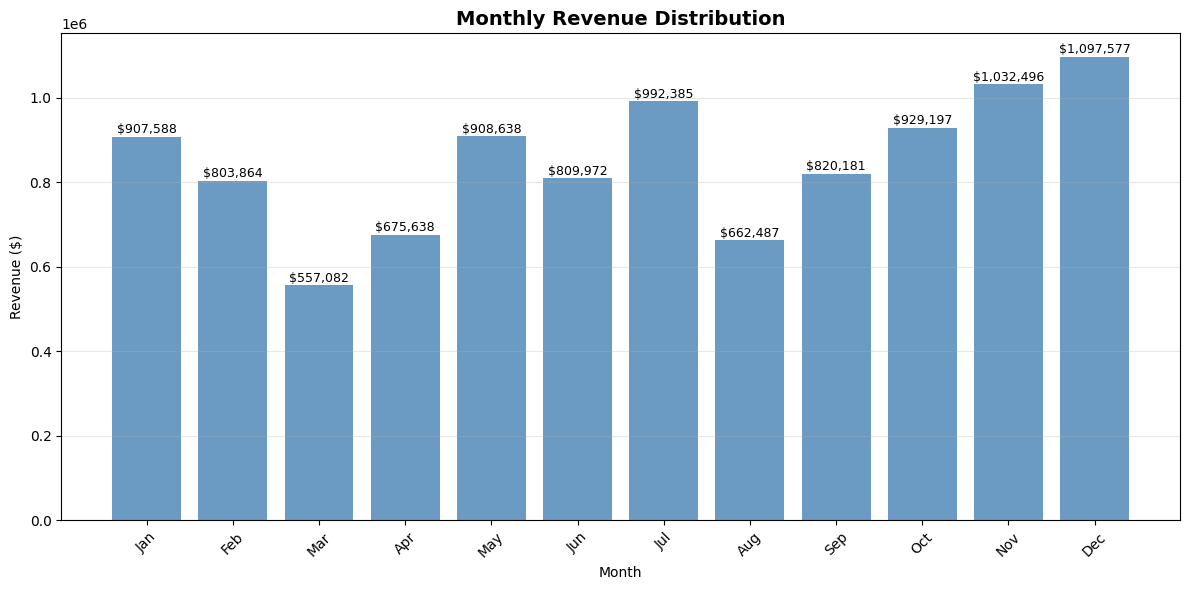

In [16]:
# 6.1 - Calculate total revenue for the entire year
total_revenue = sales_df['Revenue'].sum()

print("ANALYSIS 1: Total Revenue")
print("=" * 50)
print(f"Total revenue generated by the company: ${total_revenue:,.2f}")

# Show monthly revenue breakdown
monthly_revenue = sales_df.groupby('Month')['Revenue'].sum()
print(f"\nMonthly revenue breakdown:")
for month, revenue in monthly_revenue.items():
    print(f"  {month}: ${revenue:,.2f}")

# Visualize monthly revenue
plt.figure(figsize=(12, 6))
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_revenue_ordered = monthly_revenue.reindex(month_order)

bars = plt.bar(month_order, monthly_revenue_ordered.values, color='steelblue', alpha=0.8)
plt.title('Monthly Revenue Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1000,
             f'${height:,.0f}', ha='center', va='bottom', fontsize=9)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

ANALYSIS 2: Highest Revenue Product
Product with highest revenue: Laptop
Revenue generated: $2,918,424.00

All products by revenue:
  Laptop: $2,918,424.00
  Smartphone: $2,069,569.00
  Camera: $1,906,257.00
  Tablet: $1,067,482.00
  Monitor: $690,782.00
  Smartwatch: $645,759.00
  Headphones: $591,336.00
  Speaker: $307,496.00


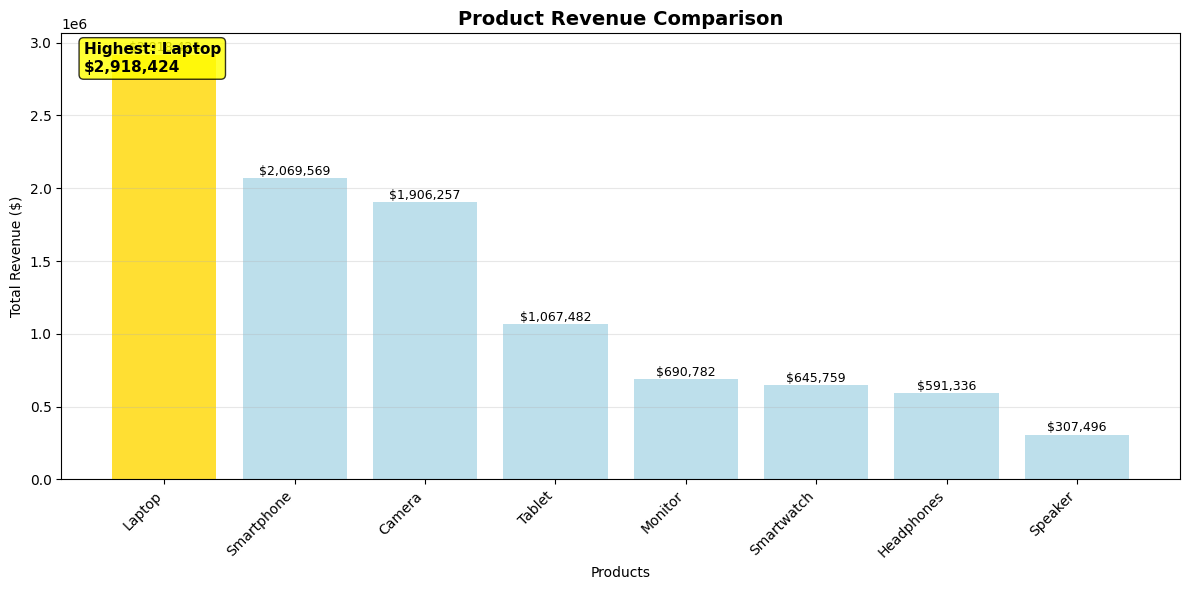

In [17]:
# 6.2 - Find product with highest revenue
product_revenue = sales_df.groupby('Product')['Revenue'].sum().sort_values(ascending=False)
highest_revenue_product = product_revenue.index[0]
highest_revenue_amount = product_revenue.iloc[0]

print("ANALYSIS 2: Highest Revenue Product")
print("=" * 50)
print(f"Product with highest revenue: {highest_revenue_product}")
print(f"Revenue generated: ${highest_revenue_amount:,.2f}")

print(f"\nAll products by revenue:")
for product, revenue in product_revenue.items():
    print(f"  {product}: ${revenue:,.2f}")

# Visualize product revenue
plt.figure(figsize=(12, 6))
colors = ['gold' if product == highest_revenue_product else 'lightblue' for product in product_revenue.index]
bars = plt.bar(product_revenue.index, product_revenue.values, color=colors, alpha=0.8)

plt.title('Product Revenue Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Products')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45, ha='right')

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 2000,
             f'${height:,.0f}', ha='center', va='bottom', fontsize=9)

# Highlight the highest revenue product
plt.text(0.02, 0.98, f'Highest: {highest_revenue_product}\n${highest_revenue_amount:,.0f}', 
         transform=plt.gca().transAxes, fontsize=11, fontweight='bold',
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.8))

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

ANALYSIS 3: Average Product Price
Average price per unit across all products: $378.96

Average price by product:
  Laptop: $820.17
  Smartphone: $629.08
  Camera: $485.67
  Tablet: $311.00
  Smartwatch: $266.83
  Monitor: $213.25
  Headphones: $201.33
  Speaker: $104.33

Price statistics:
  Minimum price: $62.00
  Maximum price: $876.00
  Median price: $288.00
  Price standard deviation: $234.00


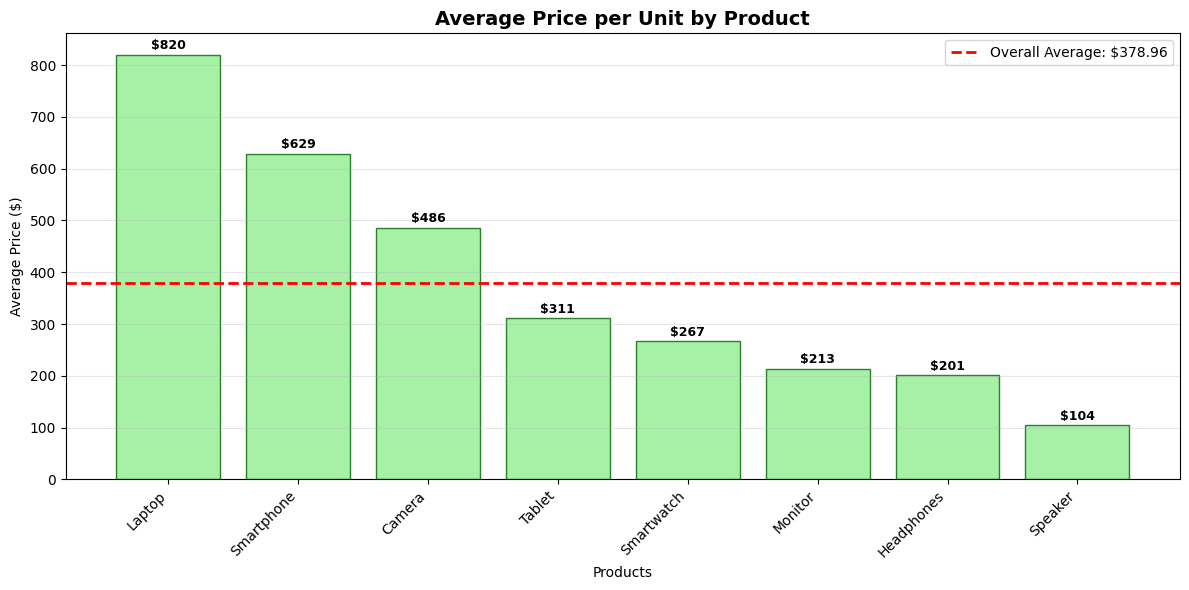

In [18]:
# 6.3 - Calculate average price of products
average_price = sales_df['Price_Per_Unit'].mean()

print("ANALYSIS 3: Average Product Price")
print("=" * 50)
print(f"Average price per unit across all products: ${average_price:.2f}")

# Calculate average price by product
avg_price_by_product = sales_df.groupby('Product')['Price_Per_Unit'].mean().sort_values(ascending=False)
print(f"\nAverage price by product:")
for product, avg_price in avg_price_by_product.items():
    print(f"  {product}: ${avg_price:.2f}")

# Additional statistics
print(f"\nPrice statistics:")
print(f"  Minimum price: ${sales_df['Price_Per_Unit'].min():.2f}")
print(f"  Maximum price: ${sales_df['Price_Per_Unit'].max():.2f}")
print(f"  Median price: ${sales_df['Price_Per_Unit'].median():.2f}")
print(f"  Price standard deviation: ${sales_df['Price_Per_Unit'].std():.2f}")

# Visualize average prices
plt.figure(figsize=(12, 6))
bars = plt.bar(avg_price_by_product.index, avg_price_by_product.values, 
               color='lightgreen', alpha=0.8, edgecolor='darkgreen', linewidth=1)

plt.title('Average Price per Unit by Product', fontsize=14, fontweight='bold')
plt.xlabel('Products')
plt.ylabel('Average Price ($)')
plt.xticks(rotation=45, ha='right')

# Add average line
plt.axhline(y=average_price, color='red', linestyle='--', linewidth=2, 
            label=f'Overall Average: ${average_price:.2f}')

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'${height:.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()